In [1]:
# Imports iniciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MaxAbsScaler, MinMaxScaler, Normalizer, RobustScaler

# Modelos
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import ElasticNet

# Se quiser usar XGBoost / LightGBM
from xgboost import XGBRegressor



In [2]:
df = pd.read_csv("/home/felipe/Projeto/Portfolio/Portfolio2/Regression_PriceHouse/data/processed/complete.csv")

del df['Unnamed: 0']

In [3]:
#criação dos score. Essa etapa será a ultima da EDA. 

df['score_escola_privada'] = (
    1.2 * np.exp(-df['dist_escolas_privadas_mais_proximo'] / 600) +
    0.6 * df['qtd_escolas_privadas_500m']
)

df['score_escola_publica'] = (
    0.6 * np.exp(-df['dist_escola_publicas_mais_proximo'] / 600) +
    0.2 * df['qtd_escola_publicas_500m']
)


df['score_hospitais'] = (
    0.8 * np.exp(-df['dist_hospital_mais_proximo'] / 1200) +
    0.4 * df['qtd_hospital_1000m']
)


df['score_mercado'] = (
    1.0 * np.exp(-df['dist_mercado_mais_proximo'] / 400) +
    0.4 * df['qtd_mercado_500m']
)


df['score_farmacia'] = (
    0.6 * np.exp(-df['dist_farmacia_mais_proximo'] / 300) +
    0.2 * df['qtd_farmacia_300m']
)


df['score_parque'] = (
    1.2 * np.exp(-df['dist_parque_mais_proximo'] / 1200) +
    0.8 * df['qtd_parque_1000m']
)


df['score_seguranca'] = (
    1.0 * np.exp(-df['dist_policia_mais_proximo'] / 1500) +
    0.3 * df['qtd_policia_500m']
)

df['score_educacao'] = (
    df['score_escola_privada']
    - 0.2 * df['score_escola_publica']
)


#Criando a coluna faixa_area
area = df['area_m2']

bins = [0, 50, 80, 120, 200, 400, area.max()]
labels = ['Até 50', '50–80', '80–120', '120–200', '200–400', '400+']

df['faixa_area'] = pd.cut(area, bins=bins, labels=labels)

df['faixa_area'].value_counts(normalize=True).sort_index()

faixa_area
Até 50     0.107443
50–80      0.151954
80–120     0.142557
120–200    0.236029
200–400    0.231083
400+       0.130935
Name: proportion, dtype: float64

In [4]:
import numpy as np

# normalizar o preço
preco_norm = (df['preco'] - df['preco'].min()) / (df['preco'].max() - df['preco'].min())

# gerar ruído aleatório
ruido = np.random.normal(0, 0.8, len(df))

# gerar nota
df['nota'] = (preco_norm * 8 + 2) + ruido

# limitar entre 0 e 10
df['nota'] = df['nota'].clip(0, 10)

In [5]:
def classificar_tipo_imovel(tipo):
    if pd.isna(tipo):
        return "outros"

    tipo = str(tipo).lower()

    if "terreno" in tipo or "lote" in tipo:
        return "terreno"

    if any(x in tipo for x in ["apartamento", "cobertura", "duplex", "flat", "kitnet"]):
        return "apartamento"

    if any(x in tipo for x in ["casa", "sobrado", "vila"]):
        return "casa"

    if any(x in tipo for x in ["comercial", "loja", "box", "galpão", "deposito", "depósito", "sala", "conjunto"]):
        return "comercial"

    if "prédio" in tipo or "edificio" in tipo or "edifício" in tipo:
        return "predio"

    return "outros"


df["tipo_imovel_cat"] = df["tipo_imovel"].apply(classificar_tipo_imovel)

In [6]:
df["is_sobrado"] = df["tipo_imovel"].str.lower().str.contains("sobrado", na=False).astype(int)
df["is_condominio"] = df["tipo_imovel"].str.lower().str.contains("condominio", na=False).astype(int)

In [7]:
#ajustando o dataframe para valores e formatos corretos. 
pd.options.display.float_format = '{:.4f}'.format

#Filtrando apenas casa, apartamento e sala comerical
df = df[
    df["tipo_imovel_cat"].isin(["casa", "apartamento", "comercial"])
].copy()

#Antes de iniciar, vamos transformar o preço em log
df['log_preco'] = np.log(df['preco'].clip(lower=1))

In [8]:
df["tipo_imovel_cat"].value_counts()

tipo_imovel_cat
casa           3561
apartamento    2352
comercial       418
Name: count, dtype: int64

In [9]:
df

,preco,rua,endereco,quartos,banheiros,area_m2,link,cidade,estado,data_coleta,...,score_farmacia,score_parque,score_seguranca,score_educacao,faixa_area,nota,tipo_imovel_cat,is_sobrado,is_condominio,log_preco
0,2300000.0000,Rua João Silvio de Lara Machado,"Sobrado para comprar com 354 m², 4 quartos, 5 ...",4.0000,5.0000,354.0000,https://www.zapimoveis.com.br/imovel/venda-sob...,ponta-grossa,pr,2026-02-09 08:28:42,...,0.0000,0.0699,0.0057,0.0019,200–400,1.1220,casa,1,0,14.6484
2,350000.0000,Rua Luiz Migdalski,"Casa de condomínio para comprar com 165 m², 4 ...",4.0000,3.0000,165.0000,https://www.zapimoveis.com.br/imovel/venda-cas...,ponta-grossa,pr,2026-02-09 08:28:42,...,0.0005,3.2593,0.3943,0.1878,120–200,1.9060,casa,0,0,12.7657
4,340000.0000,Rua Capitão Goes de Moraes,"Casa de condomínio para comprar com 80 m², 3 q...",3.0000,2.0000,80.0000,https://www.zapimoveis.com.br/imovel/venda-cas...,ponta-grossa,pr,2026-02-09 08:28:42,...,0.0004,6.4616,0.6844,-0.0612,50–80,1.7554,casa,0,0,12.7367
16,750000.0000,Rua Sebastião Paraná,"Casa para comprar com 260 m², 4 quartos, 3 ban...",4.0000,3.0000,260.0000,https://www.zapimoveis.com.br/imovel/venda-cas...,ponta-grossa,pr,2026-02-09 08:28:42,...,0.0022,1.7900,0.3703,0.0455,200–400,2.5423,casa,0,0,13.5278
20,114914.0000,Rua Recanto dos Pássaros,"Casa para comprar com 130 m², 2 quartos, 1 ban...",2.0000,1.0000,130.0000,https://www.zapimoveis.com.br/imovel/venda-cas...,ponta-grossa,pr,2026-02-09 08:28:42,...,0.0000,0.0000,0.0000,0.0000,120–200,1.7188,casa,0,0,11.6519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,1500000.0000,Avenida União Pan-americana,"Casa de condomínio para comprar com 217 m², 3 ...",3.0000,4.0000,217.0000,https://www.zapimoveis.com.br/imovel/venda-cas...,ponta-grossa,pr,2026-02-09 09:09:06,...,0.0000,3.8481,0.3669,-0.0466,200–400,2.3771,casa,0,0,14.2210
8125,2000000.0000,Rua Octaviano Macedo Ribas,"Casa para comprar com 370 m², 8 quartos, 5 ban...",8.0000,5.0000,370.0000,https://www.zapimoveis.com.br/imovel/venda-cas...,ponta-grossa,pr,2026-02-09 09:09:06,...,0.0005,5.0822,1.0829,0.1372,200–400,1.7565,casa,0,0,14.5087
8127,1310000.0000,Rua Lauro Marcondes Ferreira,"Casa para comprar com 310 m², 1 quarto, 1 banh...",1.0000,1.0000,310.0000,https://www.zapimoveis.com.br/imovel/venda-cas...,ponta-grossa,pr,2026-02-09 09:09:06,...,0.4584,6.5704,0.3554,0.1421,200–400,3.0876,casa,0,0,14.0855
8129,1200000.0000,Rua Benjamin Constant,"Apartamento para comprar com 123 m², 3 quartos...",3.0000,3.0000,123.0000,https://www.zapimoveis.com.br/imovel/venda-apa...,ponta-grossa,pr,2026-02-09 09:09:06,...,0.6893,13.0223,1.1441,1.1825,120–200,2.8286,apartamento,0,0,13.9978


### DEFINIÇÃO DAS COLUNAS

In [10]:
num_features = [
    'quartos', 'banheiros', 'vagas_garagem', 'area_m2',
    'score_escola_privada', 'score_escola_publica',
    'score_hospitais', 'score_mercado',
    'score_farmacia', 'score_parque', 'score_seguranca', 'is_sobrado', 'nota'
]

#cat_features = ['bairro', 'faixa_area']
cat_features = ['tipo_imovel_cat']
target = 'log_preco'


In [11]:
from sklearn.model_selection import train_test_split

X = df[num_features + cat_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [12]:
X_train

,quartos,banheiros,vagas_garagem,area_m2,score_escola_privada,score_escola_publica,score_hospitais,score_mercado,score_farmacia,score_parque,score_seguranca,is_sobrado,nota,tipo_imovel_cat
5439,1.0000,1.0000,1.0000,30.0000,0.1787,0.2141,0.1645,1.6255,0.0069,8.1005,0.4716,0,1.0633,apartamento
7081,3.0000,4.0000,2.0000,250.0000,3.9614,1.0358,1.0369,1.2835,0.7385,9.7418,0.6001,1,1.3451,casa
1610,3.0000,2.0000,4.0000,110.0000,0.5177,0.5499,0.2432,1.1421,0.1345,4.9972,0.4066,1,1.8150,casa
7887,3.0000,3.0000,2.0000,172.0000,1.3893,0.4830,2.2275,1.7928,0.0047,7.2824,1.0835,0,1.9717,apartamento
2628,4.0000,4.0000,4.0000,300.0000,0.3515,0.5152,0.1507,0.2280,0.0311,4.2281,0.2579,1,2.7634,casa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4812,2.0000,1.0000,1.0000,78.0000,0.3811,0.5512,0.1424,0.1117,0.0053,7.0301,0.3172,0,0.4894,casa
6585,3.0000,2.0000,3.0000,179.0000,1.4007,0.5920,1.4778,1.1566,0.0075,4.9235,0.5102,0,1.5702,casa
6645,2.0000,3.0000,1.0000,105.0000,1.7329,1.0513,2.5578,0.6984,0.1211,8.2479,0.6601,0,0.6558,apartamento
6851,3.0000,1.0000,2.0000,130.0000,1.1762,0.4716,2.1439,2.1213,0.0044,8.1618,1.9709,0,1.8865,apartamento


## 🛠️ Criando um Outlier Capper simples (quantis)

### Scikit-learn não tem nativo, então criamos um transformer:

In [13]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd

class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.q_low_ = X.quantile(self.lower)
        self.q_high_ = X.quantile(self.upper)
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.clip(self.q_low_, self.q_high_, axis=1)


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler


In [15]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('outliers', QuantileClipper(0.01, 0.99)),
    ('scaler', StandardScaler())  # depois vamos trocar
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop=None, handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ]
)


In [16]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [17]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001),
    'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5),

    'RandomForest': RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    'GradientBoosting': GradientBoostingRegressor(random_state=42),

    'XGBoost': XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),
    'DecisionTree': DecisionTreeRegressor(random_state=42)
}

scalers = {
    'None': None,
    'MaxAbsScaler': MaxAbsScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'Normalizer': Normalizer(),
    'RobustScaler': RobustScaler(),
    'StandardScaler': StandardScaler()
}


In [18]:
results = []

# Depois, no loop, use esta abordagem
for model_name, model in models.items():
    for scaler_name, scaler in scalers.items():
        
        # Criar um novo pipeline numérico com o scaler atual
        num_pipeline = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('outliers', QuantileClipper(0.01, 0.99)),
            ('scaler', scaler if scaler is not None else 'passthrough')
        ])
        
        # Criar um novo preprocessor
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', num_pipeline, num_features),
                ('cat', cat_pipeline, cat_features)  # cat_pipeline já definido
            ]
        )
        
        pipe = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ])
        
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        results.append({
            'Model': model_name,
            'Scaler': scaler_name,
            'R2': r2,
            'RMSE': rmse,
            'MAE': mae,
            'MAPE': mape
        })


In [19]:
results_df = pd.DataFrame(results)

print(results_df.sort_values(
    by=['R2', 'RMSE'],
    ascending=[False, True]
).reset_index(drop=True))


               Model          Scaler     R2   RMSE    MAE   MAPE
0            XGBoost    RobustScaler 0.8336 0.3362 0.2467 0.0185
1            XGBoost  StandardScaler 0.8332 0.3365 0.2469 0.0185
2            XGBoost            None 0.8331 0.3367 0.2464 0.0184
3            XGBoost    MaxAbsScaler 0.8331 0.3367 0.2464 0.0184
4            XGBoost    MinMaxScaler 0.8331 0.3367 0.2464 0.0184
5       RandomForest            None 0.8117 0.3576 0.2548 0.0190
6       RandomForest  StandardScaler 0.8112 0.3580 0.2548 0.0191
7       RandomForest    MaxAbsScaler 0.8112 0.3581 0.2551 0.0191
8       RandomForest    RobustScaler 0.8111 0.3581 0.2551 0.0191
9       RandomForest    MinMaxScaler 0.8110 0.3582 0.2552 0.0191
10  GradientBoosting            None 0.7918 0.3760 0.2798 0.0210
11  GradientBoosting  StandardScaler 0.7918 0.3760 0.2798 0.0210
12  GradientBoosting    RobustScaler 0.7918 0.3760 0.2801 0.0210
13  GradientBoosting    MaxAbsScaler 0.7917 0.3761 0.2799 0.0210
14  GradientBoosting    M

## Criando o gráfico de Shap para interpretação do modelo

In [20]:
import shap
import matplotlib.pyplot as plt

# Pipeline numérico final
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('outliers', QuantileClipper(0.01, 0.99)),
    ('scaler', StandardScaler())
])

# Pipeline categórico
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop=None, handle_unknown='ignore', sparse_output=False))
])

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ]
)

# Modelo final
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

pipe.fit(X_train, y_train)


/home/felipe/anaconda3/envs/regression/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## 2️⃣ Extrair dados transformados + nomes das features

### ⚠️ Passo crítico: SHAP não entende Pipeline, só o modelo + matriz final.

In [21]:
# Dados transformados
X_train_transformed = pipe.named_steps['preprocessor'].transform(X_train)

# Nomes das features após o OneHot
num_feature_names = num_features

cat_feature_names = (
    pipe.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(cat_features)
)

feature_names = list(num_feature_names) + list(cat_feature_names)


In [22]:
feature_names

['quartos',
 'banheiros',
 'vagas_garagem',
 'area_m2',
 'score_escola_privada',
 'score_escola_publica',
 'score_hospitais',
 'score_mercado',
 'score_farmacia',
 'score_parque',
 'score_seguranca',
 'is_sobrado',
 'nota',
 'tipo_imovel_cat_apartamento',
 'tipo_imovel_cat_casa',
 'tipo_imovel_cat_comercial']

In [23]:
explainer = shap.Explainer(
    pipe.named_steps['model'],
    X_train_transformed,
    feature_names=feature_names
)

shap_values = explainer(X_train_transformed)


 98%|===================| 4962/5064 [00:36<00:00]        

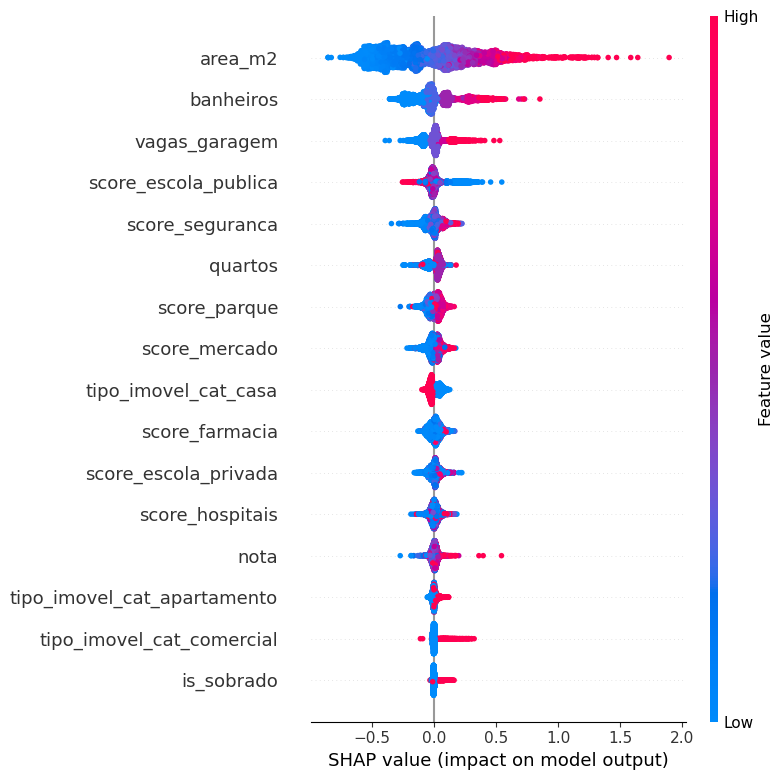

In [24]:
shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=feature_names,
    show=True
)


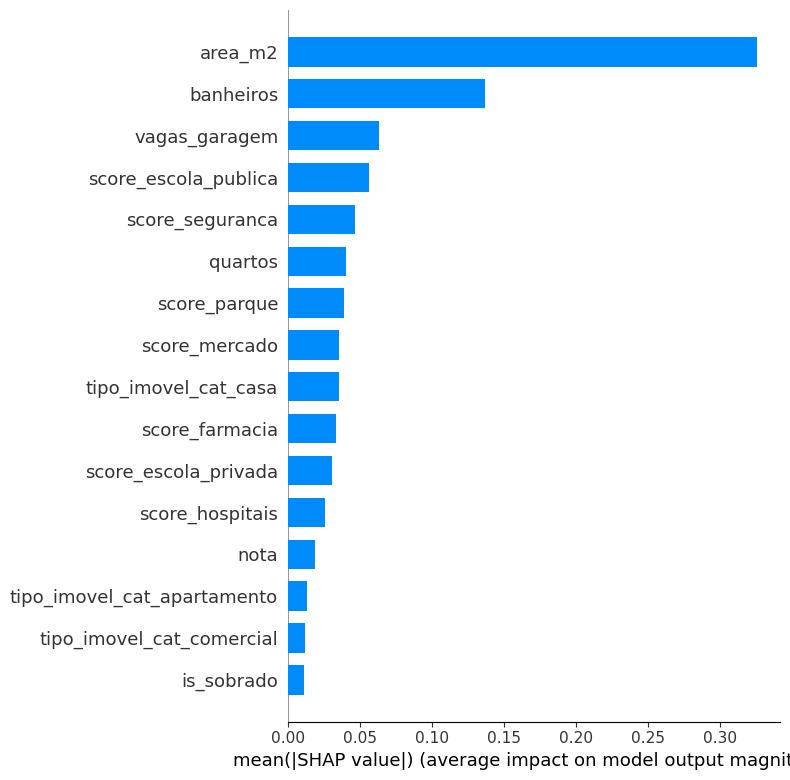

In [25]:
shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)


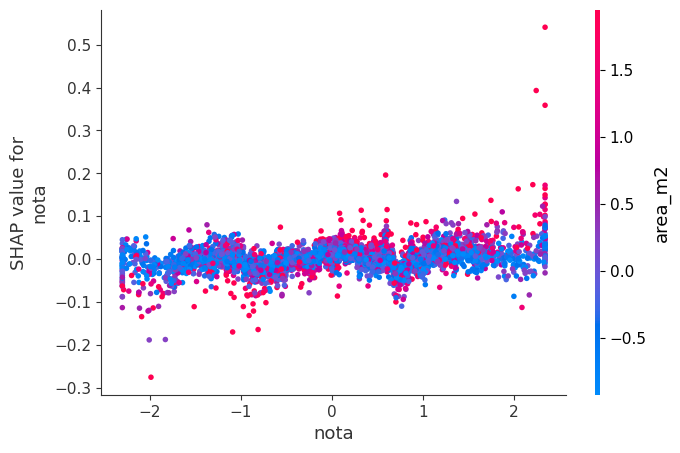

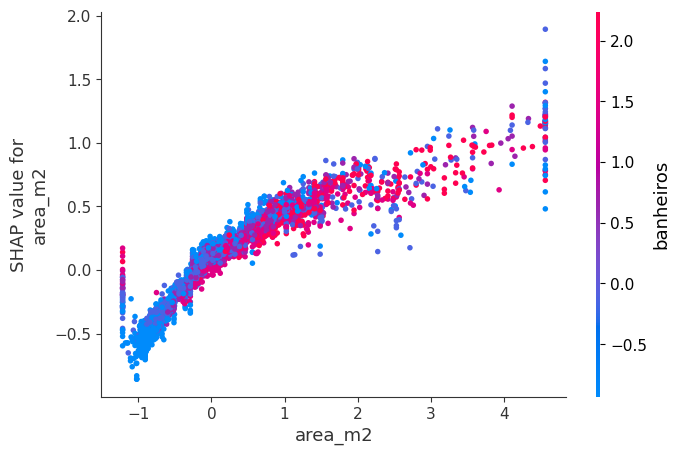

In [26]:
shap.dependence_plot(
    "nota",
    shap_values.values,
    X_train_transformed,
    feature_names=feature_names
)

shap.dependence_plot(
    "area_m2",
    shap_values.values,
    X_train_transformed,
    feature_names=feature_names
)


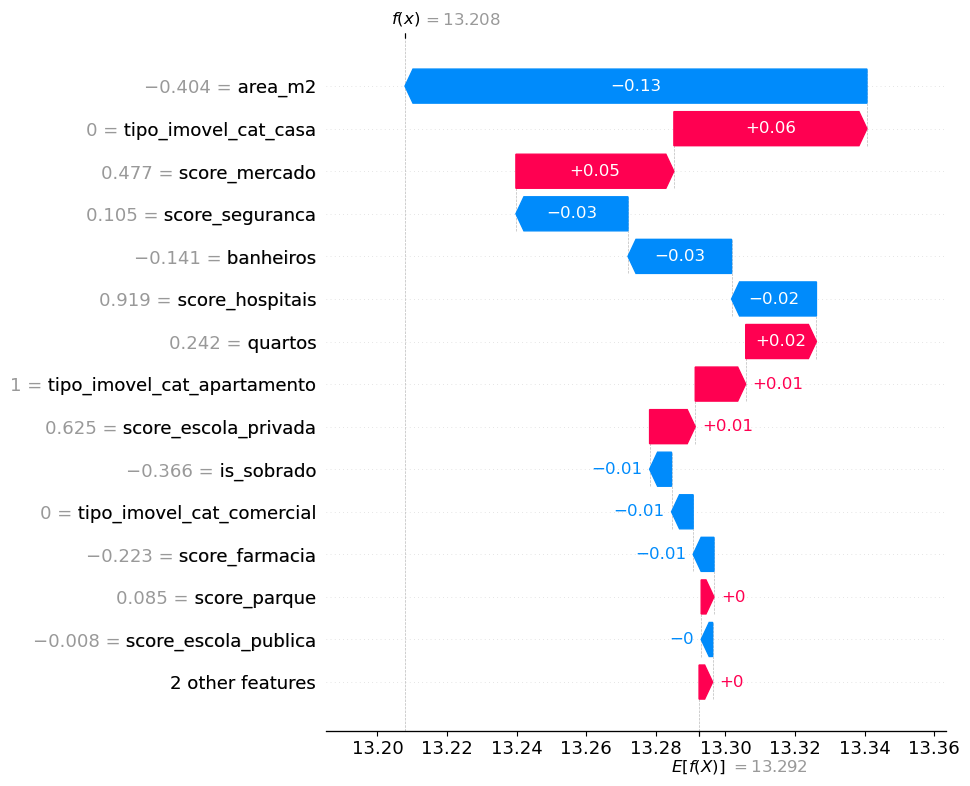

In [27]:
idx = 10  # qualquer índice

shap.plots.waterfall(
    shap_values[idx],
    max_display=15
)


In [28]:
import numpy as np

beta_0 = 13.29
preco_base = np.exp(beta_0)

preco_base

np.float64(591253.4181513096)

# 🧠 Conclusão dos Resultados — SHAP Values

## Interpretação do Modelo via SHAP Values

A análise dos SHAP values foi utilizada para interpretar tanto o comportamento global do modelo quanto previsões individuais, permitindo avaliar a coerência econômica e estatística das variáveis explicativas utilizadas.

### Importância Global das Variáveis

Os resultados indicam que os principais determinantes do preço dos imóveis são variáveis estruturais, com destaque para:

- **Área do imóvel (area_m2)**  
- **Número de banheiros**
- **Número de vagas de garagem**
- **Número de quartos**

Essas variáveis apresentaram os maiores valores absolutos médios de SHAP, indicando que são os principais fatores responsáveis pela variação do preço previsto pelo modelo. O comportamento observado é consistente com a teoria econômica e com a literatura do mercado imobiliário, reforçando a validade do modelo.

### Variáveis de Acessibilidade e Infraestrutura

Variáveis associadas à infraestrutura urbana e serviços, como:

- Score de segurança  
- Score de escolas públicas e privadas  
- Proximidade a mercados, parques e hospitais  

apresentaram impacto relevante, porém secundário. Os SHAP values indicam que melhores condições de acesso e qualidade urbana tendem a aumentar o valor dos imóveis, embora com menor magnitude quando comparadas às características físicas do imóvel.

### Efeito Espacial e Bairros

As variáveis categóricas relacionadas aos bairros, modeladas via One-Hot Encoding, apresentaram impacto individual menor, porém estatisticamente consistente. Esses efeitos capturam heterogeneidades espaciais não totalmente explicadas pelas variáveis estruturais e funcionam como efeitos fixos de localização, refletindo diferenças socioeconômicas, urbanísticas e de infraestrutura entre regiões.

### Interpretação Local das Previsões

A análise local (waterfall plot) demonstra como o modelo parte do valor médio esperado e ajusta a previsão final de acordo com as características específicas de cada imóvel. Observa-se que:
- Valores acima da média em atributos estruturais elevam o preço previsto;
- Valores abaixo da média reduzem o preço, mesmo em imóveis localizados em bairros valorizados.

### Conclusão Geral

Os SHAP values confirmam que o modelo apresenta:
- Coerência econômica;
- Estabilidade interpretativa;
- Transparência na tomada de decisão.

Além disso, os resultados reforçam os achados obtidos nos testes de inferência estatística (ANOVA e regressão), validando o uso do modelo como ferramenta confiável para análise e precificação de imóveis em ambiente produtivo.


## 🔧 Exemplo de Estrutura com Optuna (XGBoost)

In [29]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import numpy as np

def objective(trial):

    model = XGBRegressor(
        n_estimators=trial.suggest_int('n_estimators', 200, 800),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha=trial.suggest_float('reg_alpha', 0.0, 1.0),
        reg_lambda=trial.suggest_float('reg_lambda', 0.0, 1.0),
        random_state=42,
        n_jobs=-1
    )

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return rmse


In [30]:
%%time

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=250)

print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)


[I 2026-03-02 10:06:13,833] A new study created in memory with name: no-name-cefcce89-ba70-49da-b2c0-40868befb854
[I 2026-03-02 10:06:13,981] Trial 0 finished with value: 0.35155422952522447 and parameters: {'n_estimators': 578, 'max_depth': 3, 'learning_rate': 0.06801416924654231, 'subsample': 0.6333929768424177, 'colsample_bytree': 0.9079907772007979, 'reg_alpha': 0.8989488754779787, 'reg_lambda': 0.5446230186791328}. Best is trial 0 with value: 0.35155422952522447.
[I 2026-03-02 10:06:14,086] Trial 1 finished with value: 0.34980278230773254 and parameters: {'n_estimators': 465, 'max_depth': 3, 'learning_rate': 0.15324296784067037, 'subsample': 0.8096214675080718, 'colsample_bytree': 0.7775116408093456, 'reg_alpha': 0.03496864607350181, 'reg_lambda': 0.08429071455871318}. Best is trial 1 with value: 0.34980278230773254.
[I 2026-03-02 10:06:14,678] Trial 2 finished with value: 0.354431063835068 and parameters: {'n_estimators': 748, 'max_depth': 8, 'learning_rate': 0.17727959363222875,

[I 2026-03-02 10:06:25,839] Trial 23 finished with value: 0.33573590184356084 and parameters: {'n_estimators': 525, 'max_depth': 6, 'learning_rate': 0.03098753448108142, 'subsample': 0.7796075121115268, 'colsample_bytree': 0.6704641237720833, 'reg_alpha': 0.5858777811926058, 'reg_lambda': 0.7385275707019648}. Best is trial 18 with value: 0.3300034288302739.
[I 2026-03-02 10:06:26,173] Trial 24 finished with value: 0.3348231035505847 and parameters: {'n_estimators': 376, 'max_depth': 8, 'learning_rate': 0.055779849681868034, 'subsample': 0.8273588984715723, 'colsample_bytree': 0.6387954456606386, 'reg_alpha': 0.40487517552962876, 'reg_lambda': 0.6400917910577377}. Best is trial 18 with value: 0.3300034288302739.
[I 2026-03-02 10:06:26,272] Trial 25 finished with value: 0.3848717789749345 and parameters: {'n_estimators': 281, 'max_depth': 4, 'learning_rate': 0.015668183836932366, 'subsample': 0.7329767792331356, 'colsample_bytree': 0.7530632547559111, 'reg_alpha': 0.5302255843053012, 're

[I 2026-03-02 10:06:33,482] Trial 46 finished with value: 0.32974924749607304 and parameters: {'n_estimators': 594, 'max_depth': 10, 'learning_rate': 0.034285537054678544, 'subsample': 0.9622765270249946, 'colsample_bytree': 0.6184672552199721, 'reg_alpha': 0.5389645715388199, 'reg_lambda': 0.18819686774943498}. Best is trial 31 with value: 0.327162542748877.
[I 2026-03-02 10:06:34,060] Trial 47 finished with value: 0.3288388155872884 and parameters: {'n_estimators': 557, 'max_depth': 9, 'learning_rate': 0.028173891936857244, 'subsample': 0.9155117786981138, 'colsample_bytree': 0.6001971979339504, 'reg_alpha': 0.6345775666982594, 'reg_lambda': 0.21654794239185654}. Best is trial 31 with value: 0.327162542748877.
[I 2026-03-02 10:06:34,807] Trial 48 finished with value: 0.33110049138921666 and parameters: {'n_estimators': 596, 'max_depth': 10, 'learning_rate': 0.0247487236899402, 'subsample': 0.9166251487230144, 'colsample_bytree': 0.6049743592810147, 'reg_alpha': 0.688764945286829, 're

[I 2026-03-02 10:06:49,250] Trial 69 finished with value: 0.3301205937745157 and parameters: {'n_estimators': 645, 'max_depth': 9, 'learning_rate': 0.033242574841384244, 'subsample': 0.9253481301988863, 'colsample_bytree': 0.6418238792730951, 'reg_alpha': 0.25215591119583447, 'reg_lambda': 0.0567783044977202}. Best is trial 31 with value: 0.327162542748877.
[I 2026-03-02 10:06:49,682] Trial 70 finished with value: 0.3290486038563869 and parameters: {'n_estimators': 497, 'max_depth': 8, 'learning_rate': 0.0435948566374438, 'subsample': 0.9546944624443573, 'colsample_bytree': 0.6119283733842503, 'reg_alpha': 0.4882390244509432, 'reg_lambda': 0.32202390133581993}. Best is trial 31 with value: 0.327162542748877.
[I 2026-03-02 10:06:50,125] Trial 71 finished with value: 0.3295647269973636 and parameters: {'n_estimators': 496, 'max_depth': 8, 'learning_rate': 0.04329611258730747, 'subsample': 0.9539334473380562, 'colsample_bytree': 0.6137679725978749, 'reg_alpha': 0.48492963508205605, 'reg_l

[I 2026-03-02 10:07:00,471] Trial 92 finished with value: 0.3501168430997435 and parameters: {'n_estimators': 496, 'max_depth': 9, 'learning_rate': 0.1999913546377501, 'subsample': 0.8716950578136367, 'colsample_bytree': 0.608438620469946, 'reg_alpha': 0.30776925150592455, 'reg_lambda': 0.007921287400740707}. Best is trial 31 with value: 0.327162542748877.
[I 2026-03-02 10:07:01,153] Trial 93 finished with value: 0.3310425763871593 and parameters: {'n_estimators': 512, 'max_depth': 9, 'learning_rate': 0.020625134882789917, 'subsample': 0.8472603989071678, 'colsample_bytree': 0.6445078008045291, 'reg_alpha': 0.2472631225580005, 'reg_lambda': 0.214825765177335}. Best is trial 31 with value: 0.327162542748877.
[I 2026-03-02 10:07:01,671] Trial 94 finished with value: 0.3307952721995554 and parameters: {'n_estimators': 483, 'max_depth': 9, 'learning_rate': 0.023382182921587728, 'subsample': 0.7133258571954382, 'colsample_bytree': 0.6202167005767543, 'reg_alpha': 0.7185758704551045, 'reg_la

[I 2026-03-02 10:07:14,824] Trial 115 finished with value: 0.3316718809406202 and parameters: {'n_estimators': 535, 'max_depth': 8, 'learning_rate': 0.025643987371307984, 'subsample': 0.9613336949354014, 'colsample_bytree': 0.6509838890847519, 'reg_alpha': 0.6616682745002025, 'reg_lambda': 0.612732519913628}. Best is trial 31 with value: 0.327162542748877.
[I 2026-03-02 10:07:15,338] Trial 116 finished with value: 0.3323908662087014 and parameters: {'n_estimators': 589, 'max_depth': 8, 'learning_rate': 0.023804010772852956, 'subsample': 0.9307950741688582, 'colsample_bytree': 0.662532720367277, 'reg_alpha': 0.6315206984513416, 'reg_lambda': 0.19409201079829036}. Best is trial 31 with value: 0.327162542748877.
[I 2026-03-02 10:07:15,730] Trial 117 finished with value: 0.3283283409793872 and parameters: {'n_estimators': 370, 'max_depth': 9, 'learning_rate': 0.03411457366501914, 'subsample': 0.7305567094507319, 'colsample_bytree': 0.6068036331405295, 'reg_alpha': 0.7356269169653458, 'reg_

[I 2026-03-02 10:07:23,979] Trial 138 finished with value: 0.3315350717639327 and parameters: {'n_estimators': 368, 'max_depth': 10, 'learning_rate': 0.04301999070712763, 'subsample': 0.7175906126948485, 'colsample_bytree': 0.6001607665373966, 'reg_alpha': 0.3871377519530216, 'reg_lambda': 0.09858605403302842}. Best is trial 127 with value: 0.3260618896997604.
[I 2026-03-02 10:07:24,432] Trial 139 finished with value: 0.33237158670438344 and parameters: {'n_estimators': 392, 'max_depth': 9, 'learning_rate': 0.048279676930985865, 'subsample': 0.7808023000770049, 'colsample_bytree': 0.6154940668592933, 'reg_alpha': 0.09347036741667591, 'reg_lambda': 0.1553622389402646}. Best is trial 127 with value: 0.3260618896997604.
[I 2026-03-02 10:07:24,800] Trial 140 finished with value: 0.3289839896720208 and parameters: {'n_estimators': 298, 'max_depth': 9, 'learning_rate': 0.02974170564258601, 'subsample': 0.7523259781523715, 'colsample_bytree': 0.6511550334830875, 'reg_alpha': 0.270437424366650

[I 2026-03-02 10:07:35,285] Trial 161 finished with value: 0.32754063844065706 and parameters: {'n_estimators': 348, 'max_depth': 10, 'learning_rate': 0.038968141179903645, 'subsample': 0.7120232572908511, 'colsample_bytree': 0.6755005532669798, 'reg_alpha': 0.2877829657013575, 'reg_lambda': 0.08454314689326406}. Best is trial 127 with value: 0.3260618896997604.
[I 2026-03-02 10:07:35,824] Trial 162 finished with value: 0.3275880677458599 and parameters: {'n_estimators': 319, 'max_depth': 10, 'learning_rate': 0.039141295644706996, 'subsample': 0.7100207828841391, 'colsample_bytree': 0.6857976802073341, 'reg_alpha': 0.3302101867384753, 'reg_lambda': 0.08769168568392066}. Best is trial 127 with value: 0.3260618896997604.
[I 2026-03-02 10:07:36,372] Trial 163 finished with value: 0.32625116155690637 and parameters: {'n_estimators': 315, 'max_depth': 10, 'learning_rate': 0.0396233703321301, 'subsample': 0.7102569933871417, 'colsample_bytree': 0.6746498541009431, 'reg_alpha': 0.282577752866

[I 2026-03-02 10:07:46,108] Trial 184 finished with value: 0.3295731164290145 and parameters: {'n_estimators': 266, 'max_depth': 10, 'learning_rate': 0.04036642482573752, 'subsample': 0.7386870370058932, 'colsample_bytree': 0.6713199137942588, 'reg_alpha': 0.29777590506762686, 'reg_lambda': 0.018761959904703987}. Best is trial 177 with value: 0.32564929009329047.
[I 2026-03-02 10:07:46,639] Trial 185 finished with value: 0.32922257198007243 and parameters: {'n_estimators': 345, 'max_depth': 10, 'learning_rate': 0.04683632569825041, 'subsample': 0.7024492596315429, 'colsample_bytree': 0.7211899894258561, 'reg_alpha': 0.3361520564192201, 'reg_lambda': 0.040502802712369265}. Best is trial 177 with value: 0.32564929009329047.
[I 2026-03-02 10:07:47,119] Trial 186 finished with value: 0.32919876449140134 and parameters: {'n_estimators': 293, 'max_depth': 10, 'learning_rate': 0.037439753710833044, 'subsample': 0.7169829720492931, 'colsample_bytree': 0.6643752284837018, 'reg_alpha': 0.2202204

[I 2026-03-02 10:07:57,501] Trial 207 finished with value: 0.3285874031974493 and parameters: {'n_estimators': 309, 'max_depth': 10, 'learning_rate': 0.03246336265602639, 'subsample': 0.7150797784191952, 'colsample_bytree': 0.7075088000639816, 'reg_alpha': 0.3448956730771534, 'reg_lambda': 0.044383440057979895}. Best is trial 177 with value: 0.32564929009329047.
[I 2026-03-02 10:07:58,099] Trial 208 finished with value: 0.32745825608075946 and parameters: {'n_estimators': 349, 'max_depth': 10, 'learning_rate': 0.0439611720072402, 'subsample': 0.6886747451388568, 'colsample_bytree': 0.6922001546181834, 'reg_alpha': 0.406914207033359, 'reg_lambda': 0.017721161173231616}. Best is trial 177 with value: 0.32564929009329047.
[I 2026-03-02 10:07:58,646] Trial 209 finished with value: 0.3337831674581288 and parameters: {'n_estimators': 370, 'max_depth': 10, 'learning_rate': 0.05154973134431668, 'subsample': 0.6973051890627837, 'colsample_bytree': 0.6950330919255037, 'reg_alpha': 0.416429408304

[I 2026-03-02 10:08:09,348] Trial 230 finished with value: 0.3280719946548742 and parameters: {'n_estimators': 318, 'max_depth': 10, 'learning_rate': 0.03470596726625435, 'subsample': 0.6989542018056235, 'colsample_bytree': 0.6697310041314559, 'reg_alpha': 0.34437279814220356, 'reg_lambda': 0.06538240915391745}. Best is trial 177 with value: 0.32564929009329047.
[I 2026-03-02 10:08:09,785] Trial 231 finished with value: 0.32831826231629674 and parameters: {'n_estimators': 266, 'max_depth': 10, 'learning_rate': 0.03736914819863239, 'subsample': 0.7142828954933111, 'colsample_bytree': 0.6806988596074819, 'reg_alpha': 0.4004279130274911, 'reg_lambda': 0.14885827274379484}. Best is trial 177 with value: 0.32564929009329047.
[I 2026-03-02 10:08:10,288] Trial 232 finished with value: 0.32805806582048797 and parameters: {'n_estimators': 275, 'max_depth': 10, 'learning_rate': 0.03982038613423195, 'subsample': 0.7081586214112988, 'colsample_bytree': 0.6779889008630678, 'reg_alpha': 0.3015658525

Best RMSE: 0.32564929009329047
Best params: {'n_estimators': 258, 'max_depth': 10, 'learning_rate': 0.045568261199042503, 'subsample': 0.6922136011895763, 'colsample_bytree': 0.6653093997397427, 'reg_alpha': 0.2687630266220123, 'reg_lambda': 0.06511400139725285}
CPU times: user 31min 49s, sys: 1min 5s, total: 32min 55s
Wall time: 2min 4s


## ✅ 1. Treinar o modelo final (XGBoost otimizado)

### 🔧 Melhores hiperparâmetros (Optuna)

In [33]:
best_params = {
    'n_estimators': 258,
    'max_depth': 10,
    'learning_rate': 0.045568261199042503,
    'subsample': 0.6922136011895763,
    'colsample_bytree': 0.6653093997397427,
    'reg_alpha': 0.2687630266220123,
    'reg_lambda': 0.06511400139725285,
    'random_state': 42,
    'n_jobs': -1
}

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('outliers', QuantileClipper(0.01, 0.99)),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ]
)

xgb_final = XGBRegressor(**best_params)

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_final)
])

final_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## ✅ 2. Avaliação final no holdout

In [34]:
y_pred = final_pipeline.predict(X_test)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.4%}")


R²   : 0.8292
RMSE : 0.3405
MAE  : 0.2442
MAPE : 1.8237%


### 🔁 Baseline: Regressão Linear (comparação honesta)

In [35]:
from sklearn.linear_model import LinearRegression

baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

baseline_pipeline.fit(X_train, y_train)
y_pred_base = baseline_pipeline.predict(X_test)

print("Baseline Linear Regression")
print(f"R²   : {r2_score(y_test, y_pred_base):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_base)):.4f}")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_base):.4f}")
print(f"MAPE : {mean_absolute_percentage_error(y_test, y_pred_base):.4%}")


Baseline Linear Regression
R²   : 0.6605
RMSE : 0.4802
MAE  : 0.3707
MAPE : 2.7705%


### ✅ 3. SHAP final (modelo otimizado)

In [88]:
# Transformar os dados
X_train_transformed = final_pipeline.named_steps['preprocessor'].transform(X_train)

feature_names = (
    num_features +
    list(
        final_pipeline.named_steps['preprocessor']
        .named_transformers_['cat']
        .named_steps['encoder']
        .get_feature_names_out(cat_features)
    )
)


In [89]:
explainer = shap.Explainer(
    final_pipeline.named_steps['model'],
    X_train_transformed,
    feature_names=feature_names
)

shap_values = explainer(X_train_transformed)


100%|===================| 5054/5064 [03:58<00:00]        

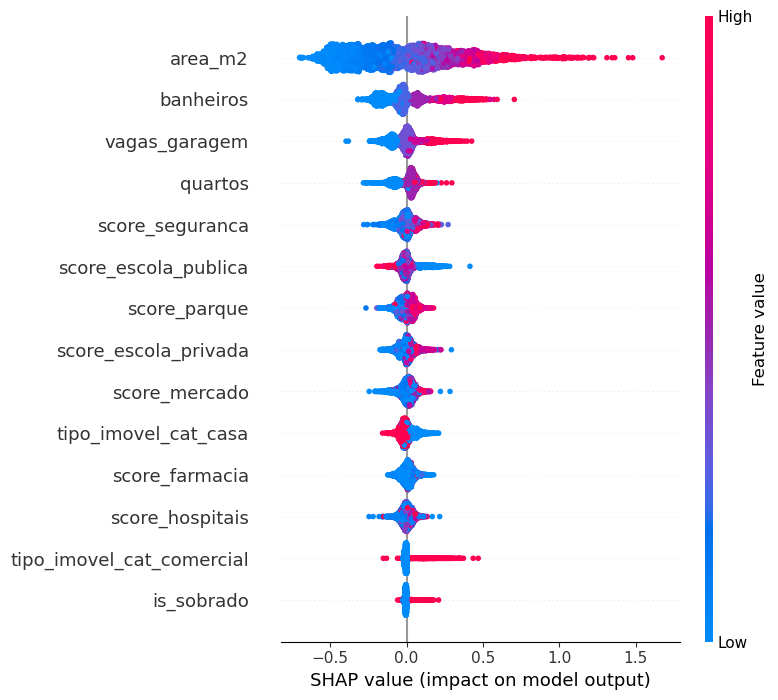

In [90]:
shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names)


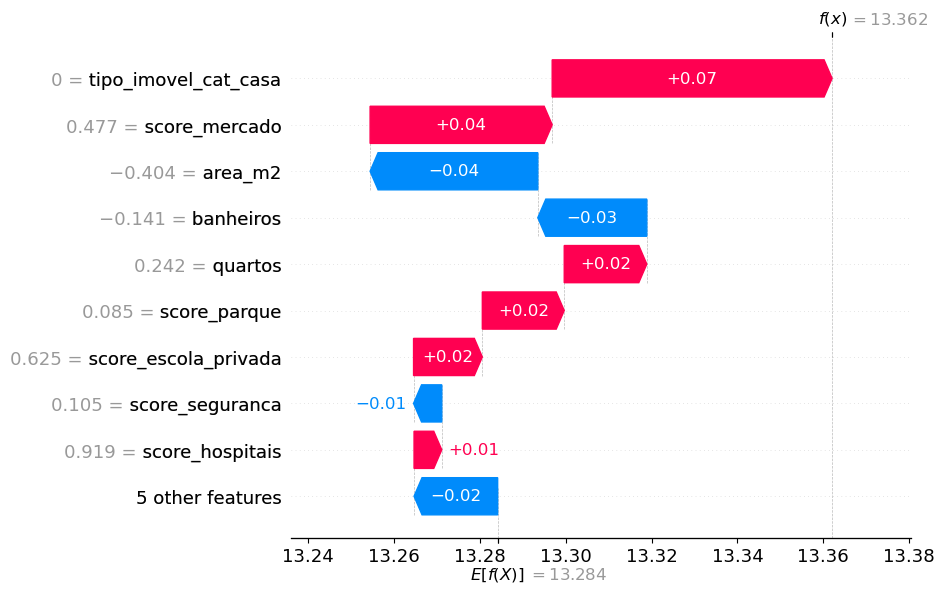

In [91]:
shap.plots.waterfall(shap_values[10])


## 💾 Salvando o modelo (pickle)

In [92]:
import pickle

with open("xgb_price_model2.pkl", "wb") as f:
    pickle.dump(final_pipeline, f)


In [94]:
with open("xgb_price_model2.pkl", "rb") as f:
    loaded_model = pickle.load(f)




In [95]:
loaded_model.predict(X_test.iloc[:5])




array([14.3945  , 12.361092, 12.70884 , 13.503214, 13.038271],
      dtype=float32)